In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from scipy.stats import mstats
import warnings; warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
sns.set_theme()

In [ ]:
file_name = 'synthetic_fraud_dataset.csv'

df = pd.read_csv(file_name)

X = df.drop("Fraud_Label", axis=1)
y = df["Fraud_Label"]

df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [4]:
df.shape

(50000, 21)

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Timestamp                     50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  F

In [7]:
df.isnull().sum()

Transaction_ID                  0
User_ID                         0
Transaction_Amount              0
Transaction_Type                0
Timestamp                       0
Account_Balance                 0
Device_Type                     0
Location                        0
Merchant_Category               0
IP_Address_Flag                 0
Previous_Fraudulent_Activity    0
Daily_Transaction_Count         0
Avg_Transaction_Amount_7d       0
Failed_Transaction_Count_7d     0
Card_Type                       0
Card_Age                        0
Transaction_Distance            0
Authentication_Method           0
Risk_Score                      0
Is_Weekend                      0
Fraud_Label                     0
dtype: int64

In [8]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

Transaction_Amount: 2260 outliers
Account_Balance: 0 outliers
IP_Address_Flag: 2510 outliers
Previous_Fraudulent_Activity: 4920 outliers
Daily_Transaction_Count: 0 outliers
Avg_Transaction_Amount_7d: 0 outliers
Failed_Transaction_Count_7d: 0 outliers
Card_Age: 0 outliers
Transaction_Distance: 0 outliers
Risk_Score: 0 outliers
Is_Weekend: 0 outliers
Fraud_Label: 0 outliers


In [9]:
# Importar librería warnings
import warnings

# Indicar que se ignoren todas las advertencias
warnings.filterwarnings('ignore')

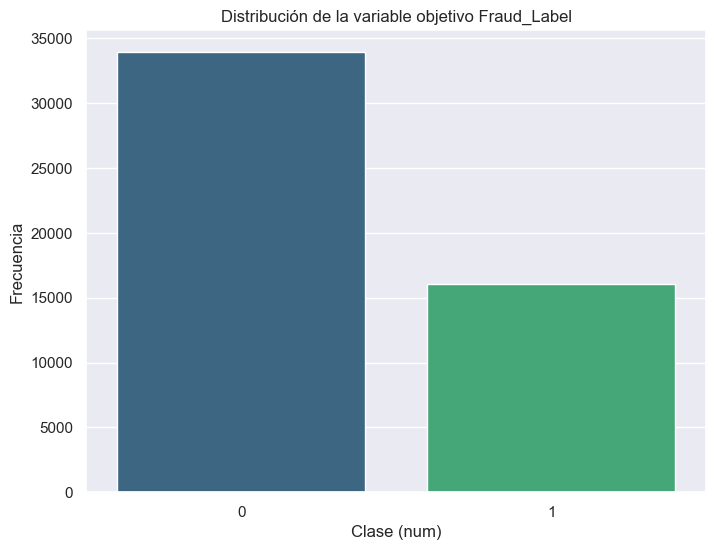

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
# Verificar la distribución de la variable objetivo 'Fraud_Label'
plt.figure(figsize=(8, 6))
sns.countplot(x=y, data=df, palette='viridis')
plt.title('Distribución de la variable objetivo Fraud_Label')
plt.xlabel('Clase (num)')
plt.ylabel('Frecuencia')
plt.show()

In [13]:
# Mostrar el conteo de cada clase
class_counts = df['Fraud_Label'].value_counts().sort_index()
print("Distribución de clases:")
print(class_counts)

# Calcular el porcentaje de cada clase
class_percentages = df['Fraud_Label'].value_counts(normalize=True).sort_index() * 100
print("\nPorcentaje de cada clase:")
print(class_percentages)

Distribución de clases:
Fraud_Label
0    33933
1    16067
Name: count, dtype: int64

Porcentaje de cada clase:
Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


In [23]:
import pandas as pd

# 1. Todas las columnas tipo object
obj_cols = df.select_dtypes(include=['object']).columns

# 2. Quitamos las que NO queremos codificar
cols_a_codificar = [c for c in obj_cols 
                    if c not in ['Transaction_ID', 'User_ID', 'Timestamp']]

# 3. Creamos dummies solo para esas columnas
df_dummies = pd.get_dummies(df, columns=cols_a_codificar, drop_first=True)

X = df_dummies.drop(columns=['Transaction_ID', 'User_ID','Timestamp' , 'Fraud_Label'])

df_dummies.head()


,Transaction_ID,User_ID,Transaction_Amount,Timestamp,Account_Balance,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,Merchant_Category_Groceries,Merchant_Category_Restaurants,Merchant_Category_Travel,Card_Type_Discover,Card_Type_Mastercard,Card_Type_Visa,Authentication_Method_OTP,Authentication_Method_PIN,Authentication_Method_Password
0,TXN_33553,USER_1834,39.79,2023-08-14 19:30:00,93213.17,0,0,7,437.63,3,65,883.17,0.8494,0,0,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False
1,TXN_9427,USER_7875,1.19,2023-06-07 04:01:00,75725.25,0,0,13,478.76,4,186,2203.36,0.0959,0,1,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
2,TXN_199,USER_2734,28.96,2023-06-20 15:25:00,1588.96,0,0,14,50.01,4,226,1909.29,0.8400,0,1,False,True,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False
3,TXN_12447,USER_2617,254.32,2023-12-07 00:31:00,76807.20,0,0,8,182.48,4,76,1311.86,0.7935,0,1,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False
4,TXN_39489,USER_2014,31.28,2023-11-11 23:44:00,92354.66,0,1,14,328.69,4,140,966.98,0.3819,1,1,False,False,True,True,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True


In [29]:
from sklearn.model_selection import train_test_split    

df_SMOTE = df_dummies.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # mantiene la proporción de clases
)

In [30]:
from imblearn.over_sampling import SMOTE
#Aplicar SMOTE para balancear las clases minoritarias
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

# Verificar la nueva distribución de clases
print("Distribución de clases después de SMOTE:")
print(y_smote.value_counts())

# Unir X_smote y y_smote en un nuevo DataFrame balanceado
df_balanced = pd.concat([pd.DataFrame(X_smote), pd.DataFrame(y_smote, columns=['Fraud_Label'])], axis=1)

Distribución de clases después de SMOTE:
Fraud_Label
0    27146
1    27146
Name: count, dtype: int64


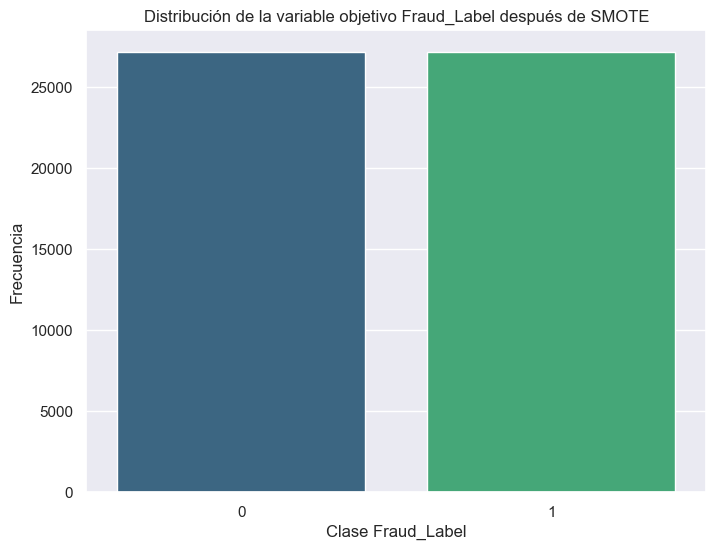

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# Verificar la nueva distribución de la variable objetivo 'num' con SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_smote, data=df_balanced, palette='viridis')
plt.title('Distribución de la variable objetivo Fraud_Label después de SMOTE')
plt.xlabel('Clase Fraud_Label')
plt.ylabel('Frecuencia')
plt.show()

In [32]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score